In [98]:
import numpy as np
from matplotlib import pyplot as plt
import qiskit as qk

from qiskit import QuantumCircuit

In [99]:
"""
From https://pysme.readthedocs.io/en/latest/_modules/gellmann.html#gellmann
"""

"""
.. module:: gellmann.py
   :synopsis: Generate generalized Gell-Mann matrices
.. moduleauthor:: Jonathan Gross <jarthurgross@gmail.com>

"""
import numpy as np
from itertools import product

def gellmann(j, k, d):
    r"""Returns a generalized Gell-Mann matrix of dimension d. According to the
    convention in *Bloch Vectors for Qubits* by Bertlmann and Krammer (2008),
    returns :math:`\Lambda^j` for :math:`1\leq j=k\leq d-1`,
    :math:`\Lambda^{kj}_s` for :math:`1\leq k<j\leq d`,
    :math:`\Lambda^{jk}_a` for :math:`1\leq j<k\leq d`, and
    :math:`I` for :math:`j=k=d`.

    :param j: First index for generalized Gell-Mann matrix
    :type j:  positive integer
    :param k: Second index for generalized Gell-Mann matrix
    :type k:  positive integer
    :param d: Dimension of the generalized Gell-Mann matrix
    :type d:  positive integer
    :returns: A genereralized Gell-Mann matrix.
    :rtype:   numpy.array

    """

    if j > k:
        gjkd = np.zeros((d, d), dtype=np.complex128)
        gjkd[j - 1][k - 1] = 1
        gjkd[k - 1][j - 1] = 1
    elif k > j:
        gjkd = np.zeros((d, d), dtype=np.complex128)
        gjkd[j - 1][k - 1] = -1.j
        gjkd[k - 1][j - 1] = 1.j
    elif j == k and j < d:
        gjkd = np.sqrt(2/(j*(j + 1)))*np.diag([1 + 0.j if n <= j
                                               else (-j + 0.j if n == (j + 1)
                                                     else 0 + 0.j)
                                               for n in range(1, d + 1)])
    else:
        gjkd = np.diag([1 + 0.j for n in range(1, d + 1)])

    return gjkd

def get_basis(d):
    r'''Return a basis of orthogonal Hermitian operators on a Hilbert space of
    dimension d, with the identity element in the last place.

    '''
    return [gellmann(j, k, d) for j, k in product(range(1, d + 1), repeat=2)]

In [100]:
g = get_basis(3)

In [101]:
# matching convention of 2407.13914

g3 = g[0]
g2 = - g[1]
g5 = g[2]
g1 = g[3]
g8 = g[4]
g7 = g[5]
g4 = g[6]
g6 = g[7]

g = [g1, g2, g3, g4, g5, g6, g7, g8]


In [102]:
# embed each of these into 4x4 matrices
g4x4 = np.zeros((8, 4, 4), dtype=np.complex128)
for i in range(8):
    zeros4x4 = np.eye(4, dtype=np.complex128)
    zeros4x4[:3, :3] = g[i]
    g4x4[i] = zeros4x4


In [103]:
g4x4

array([[[ 0.        +0.j,  1.        +0.j,  0.        +0.j,
          0.        +0.j],
        [ 1.        +0.j,  0.        +0.j,  0.        +0.j,
          0.        +0.j],
        [ 0.        +0.j,  0.        +0.j,  0.        +0.j,
          0.        +0.j],
        [ 0.        +0.j,  0.        +0.j,  0.        +0.j,
          1.        +0.j]],

       [[-0.        -0.j,  0.        +1.j, -0.        -0.j,
          0.        +0.j],
        [-0.        -1.j, -0.        -0.j, -0.        -0.j,
          0.        +0.j],
        [-0.        -0.j, -0.        -0.j, -0.        -0.j,
          0.        +0.j],
        [ 0.        +0.j,  0.        +0.j,  0.        +0.j,
          1.        +0.j]],

       [[ 1.        +0.j,  0.        +0.j,  0.        +0.j,
          0.        +0.j],
        [ 0.        +0.j, -1.        +0.j,  0.        +0.j,
          0.        +0.j],
        [ 0.        +0.j,  0.        +0.j,  0.        +0.j,
          0.        +0.j],
        [ 0.        +0.j,  0.        +0

In [104]:
op4x4 = []
for i in range(8):
    op4x4.append(qk.quantum_info.Operator(g4x4[i]))

In [105]:
import sys
sys.path.append('SBN/')

from hamiltonians import *
from qiskit.circuit import Parameter as P

dm31 = P('dm31')
E = P('E')
N = P('N')
#mu=dm31*N/(2*E) #* 1e-8
mu = dm31 * N / (2 * E)

In [106]:
# from qiskit.circuit.library import HamiltonianGate

# t = P('t')

# qc = QuantumCircuit(4)

# a, b = P('a'), P('b')

# for i in range(8):
#     op = op4x4[i].tensor(op4x4[i])
#     gate = HamiltonianGate(op, J_ij(a, b, E, mu, N)*t, label='g' + str(i + 1))
#     qc.append(gate, [0, 1, 2, 3])


In [120]:
t = P('t')
a, b = P('a'), P('b')
qc = QuantumCircuit(4)

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import PauliEvolutionGate

op = op4x4[0].tensor(op4x4[0]).data + op4x4[1].tensor(op4x4[1]).data 
h = SparsePauliOp.from_operator(op)
g = PauliEvolutionGate(h, time=J_ij(a, b, E, mu, N)*t, label='s1')
qc.append(g, [0, 1, 2, 3])

op = op4x4[3].tensor(op4x4[3]).data + op4x4[4].tensor(op4x4[4]).data 
h = SparsePauliOp.from_operator(op)
g = PauliEvolutionGate(h, time=J_ij(a, b, E, mu, N)*t, label='s2')
qc.append(g, [0, 1, 2, 3])

op = op4x4[5].tensor(op4x4[5]).data + op4x4[6].tensor(op4x4[6]).data 
h = SparsePauliOp.from_operator(op)
g = PauliEvolutionGate(h, time=J_ij(a, b, E, mu, N)*t, label='s3')
qc.append(g, [0, 1, 2, 3])

op = op4x4[2].tensor(op4x4[2]).data
h = SparsePauliOp.from_operator(op)
g = PauliEvolutionGate(h, time=J_ij(a, b, E, mu, N)*t, label='g3')
qc.append(g, [0, 1, 2, 3])

op = op4x4[7].tensor(op4x4[7]).data
h = SparsePauliOp.from_operator(op)
g = PauliEvolutionGate(h, time=J_ij(a, b, E, mu, N)*t, label='g8')
qc.append(g, [0, 1, 2, 3])

# for i in [0, 1 , 3, 4, 5, 6, 2, 7]:
#     op = op4x4[i].tensor(op4x4[i])
#     h = SparsePauliOp.from_operator(op)
#     g = PauliEvolutionGate(h, time=J_ij(a, b, E, mu, N)*t, label='g' + str(i + 1))
#     qc.append(g, [0, 1, 2, 3])

    

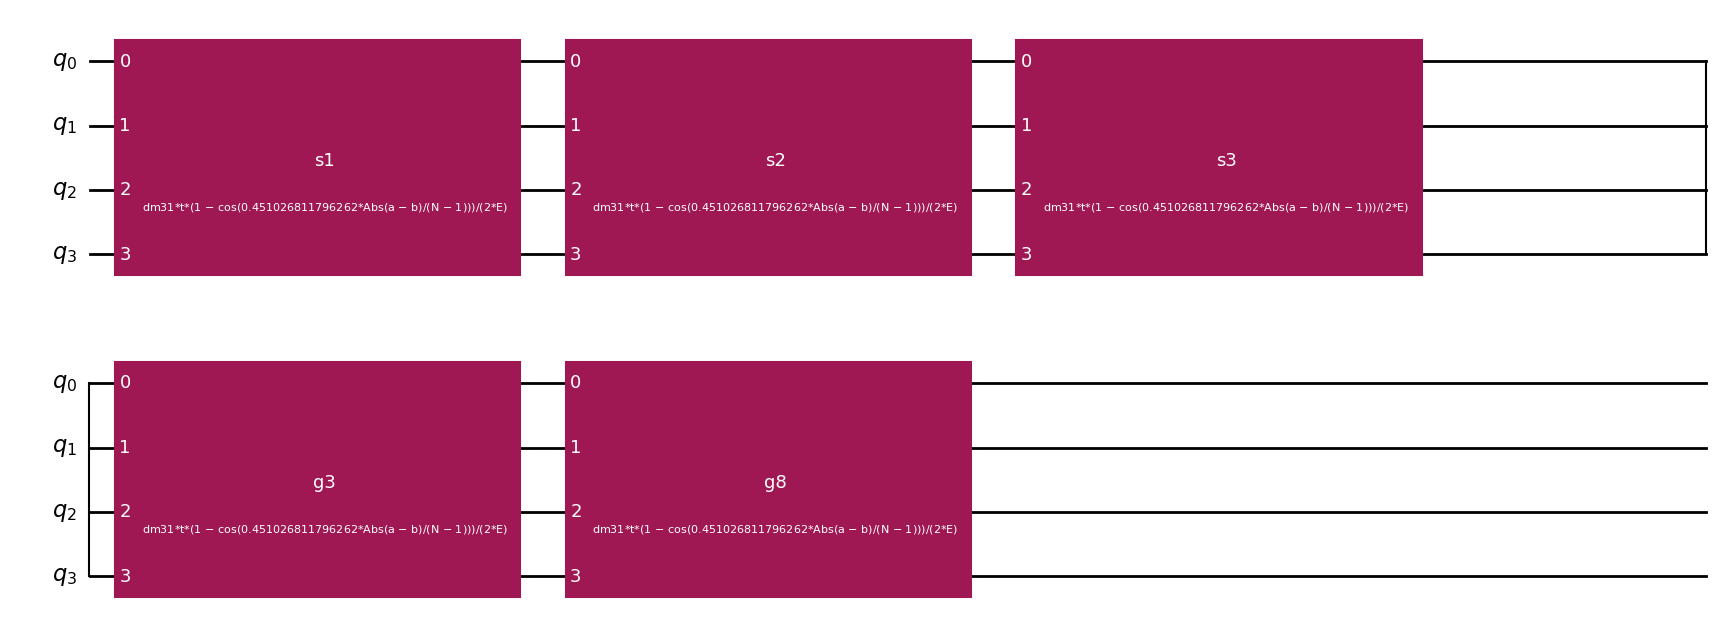

In [121]:
qc.draw('mpl')

In [122]:
from qiskit import transpile

In [123]:
tqc = transpile(qc, basis_gates=['cz', 'sx', 'x', 'rz'], optimization_level=3)

In [124]:
sys.path.append('SBN/')
from helpers import *

In [125]:
count_2q(tqc)

344

In [ ]:
Q1 = SparsePauliOp.from_list([
    ('XX', 1/2),
    ('YY', 1/2),
])

Q2 = SparsePauliOp.from_list([
    ('YX', 1/2),
    ('XY', -1/2),
])

Q3 = SparsePauliOp.from_list([
    ('ZI', 1/2),
    ('IZ', -1/2),
])

Q4 = SparsePauliOp.from_list([
    ('ZI', 1/2),
    ('IZ', -1/2),
])